# SAMOS pipeline walkthrough — Step06

This notebook documents **Step06** of the SAMOS pipeline: science-frame construction, pixel-flat correction, and slit rectification into **TRACECOORDS**.

Step06 is the stage that transforms the cleaned science exposures into the flat-fielded, trace-aware, slit-resolved 2D products used downstream for wavelength calibration and extraction.

The Step06 flow is:

```text
Step03.5 science frames
        ↓
Step06a → full-frame FinalScience mosaic
        ↓
Step06b → pixel-flat corrected science (EVEN / ODD)
        ↓
Step06c → TRACECOORDS slitlets (rectified, one extension per slit)
```

This notebook is designed to make both the **infrastructure** and the **scientific flow** explicit.


In [1]:
from pathlib import Path
import os
import sys

def find_repo_root(start: Path):
    candidates = [start] + list(start.parents)
    for p in candidates:
        cfg_dir = p / "config"
        if cfg_dir.is_dir() and (cfg_dir / "__init__.py").exists():
            return p
    return None

repo_env = os.environ.get("SAMOS_REPO_ROOT", "").strip()
if repo_env:
    REPO_ROOT = Path(repo_env).expanduser().resolve()
else:
    REPO_ROOT = find_repo_root(Path.cwd())

if REPO_ROOT is None:
    raise RuntimeError(
        "Could not find the SAMOS repository root. "
        "Run this notebook from inside the repo tree, or set SAMOS_REPO_ROOT."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import config

print("Repo root        :", REPO_ROOT)
print("Step03.5 input   :", config.ST03P5_ROWSTRIPE)
print("Step04 output dir:", config.ST04_TRACES)
print("Step05 output dir:", config.ST05_PIXFLAT)
print("Step06 output dir:", config.ST06_SCIENCE)
print("Science files    :", getattr(config, "SCIENCE_FILES", []))


Repo root        : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
Step03.5 input   : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe
Step04 output dir: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces
Step05 output dir: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/05_pixflat
Step06 output dir: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science
Science files    : ['021.dolidze_biascorr_cr_rowcorr.f

## Notebook infrastructure

This notebook may live outside the repository root, for example under `drivers/Jupyter/`. Because of that, all pipeline and QC scripts should be executed through a helper that resolves paths relative to `REPO_ROOT`, not relative to the notebook working directory.


In [2]:
from pathlib import Path
import subprocess
import os
import sys

PYTHON = sys.executable

def run_repo_script(relpath: str, *args, check: bool = True):
    script = REPO_ROOT / relpath
    if not script.exists():
        raise FileNotFoundError(f"Script not found: {script}")

    env = os.environ.copy()
    old_pp = env.get("PYTHONPATH", "")
    env["PYTHONPATH"] = str(REPO_ROOT) + (os.pathsep + old_pp if old_pp else "")

    cmd = [PYTHON, str(script), *map(str, args)]
    print("Running:", " ".join(cmd))
    print("cwd     :", REPO_ROOT)
    print("PYTHONPATH:", env["PYTHONPATH"])

    return subprocess.run(
        cmd,
        check=check,
        cwd=str(REPO_ROOT),
        env=env,
    )

def repo_path(relpath: str) -> Path:
    return REPO_ROOT / relpath


## 1. Conceptual structure of Step06

Step06 has three distinct sub-steps.

### Step06a — build the baseline science mosaic
This combines the Step03.5 science exposures into a single full-frame product, usually normalized to **ADU/s**.

### Step06b — apply the Step05 pixel flat
This divides the Step06a mosaic by the pixel flat, but only inside the Step04 slit mask. It is run separately for `EVEN` and `ODD`.

### Step06c — rectify slitlets into TRACECOORDS
This uses the Step04 geometry to map the curved slit traces into rectangular slit images. This is still a **purely geometric** operation: no wavelength calibration is applied here.


## 2. Critical dependencies and file flow

### Step06a reads
- Step03.5 science exposures from `config.ST03P5_ROWSTRIPE`
- `config.SCIENCE_FILES`

### Step06b reads
- Step06a mosaic from `config.ST06_SCIENCE`
- Step05 pixel flat from `config.ST05_PIXFLAT`
- Step04 trace mask from `config.ST04_TRACES`

### Step06c reads
- Step06b corrected science
- Step04 slitid map
- Step04 geometry FITS
- Step04 slit table

So the practical dependency chain is:

```text
Step03.5 science → Step06a
Step06a + Step05 pixflat + Step04 mask → Step06b
Step06b + Step04 slitid/geometry/slit_table → Step06c
```


In [3]:
# Check that the key Step06 infrastructure exists
from pathlib import Path

st03p5 = Path(config.ST03P5_ROWSTRIPE)
st04 = Path(config.ST04_TRACES)
st05 = Path(config.ST05_PIXFLAT)
st06 = Path(config.ST06_SCIENCE)

print("Step03.5 science inputs:")
for name in getattr(config, "SCIENCE_FILES", []):
    p = st03p5 / Path(name).name
    print(f"{p.exists():5}  {p}")

print("\nStep04 core files:")
for p in [
    st04 / "Even_traces_geometry.fits",
    st04 / "Odd_traces_geometry.fits",
    st04 / "Even_traces_slitid.fits",
    st04 / "Odd_traces_slitid.fits",
    st04 / "Even_traces_slit_table.csv",
    st04 / "Odd_traces_slit_table.csv",
]:
    print(f"{p.exists():5}  {p}")

print("\nStep05 core files:")
for p in [
    Path(getattr(config, "PIXFLAT_EVEN", st05 / "PixelFlat_from_quartz_diff_EVEN.fits")),
    Path(getattr(config, "PIXFLAT_ODD",  st05 / "PixelFlat_from_quartz_diff_ODD.fits")),
]:
    print(f"{p.exists():5}  {p}")


Step03.5 science inputs:
    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe/021.dolidze_biascorr_cr_rowcorr.fits
    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe/022.dolidze_biascorr_cr_rowcorr.fits
    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe/023.dolidze_biascorr_cr_rowcorr.fits
    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe/024.dolidze_biascorr_cr_rowcorr.fits

Step04 core files:
    1  /Users/robberto/Library/CloudSto

## 3. Step06a — build the FinalScience mosaic

Step06a combines the Step03.5 science exposures into the full-frame baseline science image.

The production script uses:
- exposure-time weighted combination
- optional sigma clipping
- optional normalization to ADU/s

The main expected output is:

```text
FinalScience_<target>_ADUperS.fits
```

This is the **reference full-frame science image** used by all later Step06 branches.


In [5]:
# Uncomment to run Step06a
#run_repo_script("pipeline/step06_science_rectify/step06a_make_final_science.py")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step06_science_rectify/step06a_make_final_science.py
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline


/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step06_science_rectify/step06a_make_final_science.py:100: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(np.where(good, stack, np.nan), axis=0)
/opt/anaconda3/envs/samos/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



Inputs / exposure times:
------------------------------------------------------------
021.dolidze_biascorr_cr_rowcorr.fits        1200.000 s
022.dolidze_biascorr_cr_rowcorr.fits        1200.000 s
023.dolidze_biascorr_cr_rowcorr.fits        1200.000 s
024.dolidze_biascorr_cr_rowcorr.fits         350.000 s
------------------------------------------------------------
Total integration time (sum EXPTIME): 3950.000 s

Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/FinalScience_dolidze_ADUperS.fits


CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step06_science_rectify/step06a_make_final_science.py'], returncode=0)

In [6]:
from pathlib import Path

st06 = Path(config.ST06_SCIENCE)
for p in sorted(st06.glob("FinalScience*_ADU*.fits")):
    print(p.name)


FinalScience_dolidze_ADUperS.fits
FinalScience_dolidze_ADUperS_pixflatcorr_EVEN_tracecoords.fits
FinalScience_dolidze_ADUperS_pixflatcorr_ODD_tracecoords.fits
FinalScience_dolidze_ADUperS_pixflatcorr_clipped_EVEN.fits
FinalScience_dolidze_ADUperS_pixflatcorr_clipped_EVEN_tracecoords.fits
FinalScience_dolidze_ADUperS_pixflatcorr_clipped_ODD.fits
FinalScience_dolidze_ADUperS_pixflatcorr_clipped_ODD_tracecoords.fits


Using: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/FinalScience_dolidze_ADUperS.fits


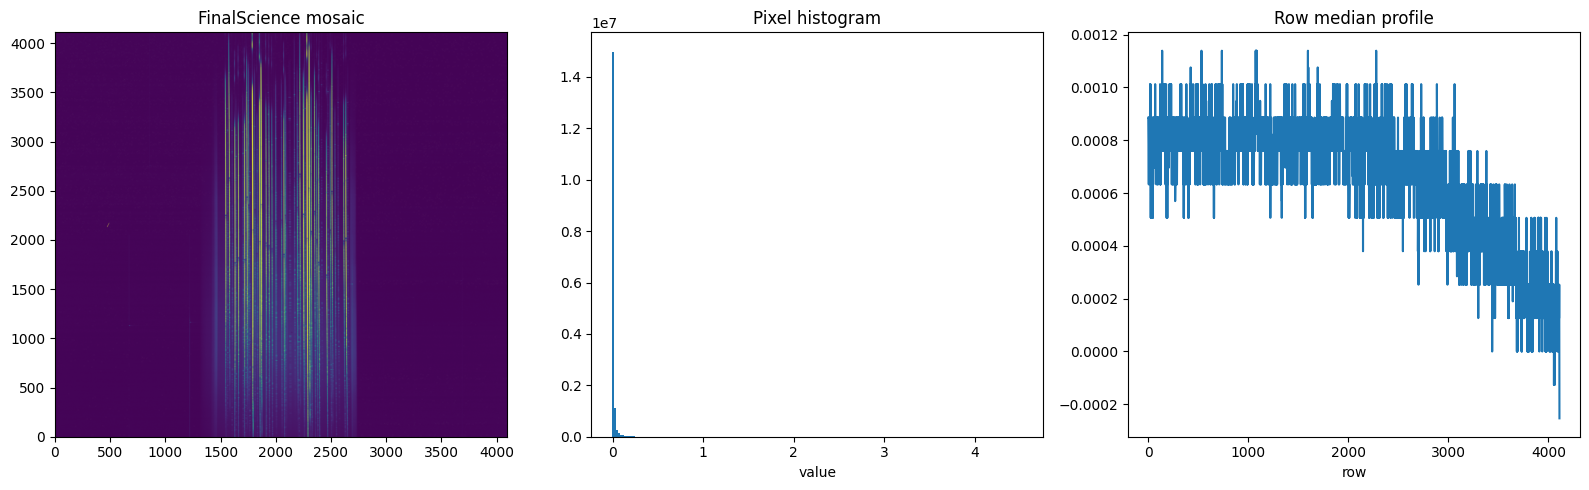

In [7]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

st06 = Path(config.ST06_SCIENCE)
science_candidates = sorted(st06.glob("FinalScience*_ADUperS.fits"))
if not science_candidates:
    science_candidates = sorted(st06.glob("FinalScience*_ADU*.fits"))

if not science_candidates:
    raise FileNotFoundError(f"No FinalScience product found in {st06}")

science_path = science_candidates[-1]
print("Using:", science_path)

img = fits.getdata(science_path)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
vmin = np.nanpercentile(img[np.isfinite(img)], 5)
vmax = np.nanpercentile(img[np.isfinite(img)], 99)

ax[0].imshow(img, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
ax[0].set_title("FinalScience mosaic")

vals = img[np.isfinite(img)]
ax[1].hist(vals.ravel(), bins=200)
ax[1].set_title("Pixel histogram")
ax[1].set_xlabel("value")

row_med = np.nanmedian(img, axis=1)
ax[2].plot(row_med)
ax[2].set_title("Row median profile")
ax[2].set_xlabel("row")

plt.tight_layout()


### Step06a QC

The Step06a QC script provides a lightweight full-frame validation of the mosaic:
- image quicklook
- histogram
- row / column median profiles
- finite-pixel fraction
- header audit


In [8]:
# Uncomment to run Step06a QC
run_repo_script("qc/step06/qc_step06a_mosaic_final.py")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step06/qc_step06a_mosaic_final.py
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline

Step06a QC — baseline FinalScience mosaic
Input  : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/FinalScience_dolidze_ADUperS.fits
Output : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/qc_step06a/step06a_mosaic_summary.png


CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step06/qc_step06a_mosaic_final.py'], returncode=0)

## 4. Step06b — apply pixel flat correction

Step06b applies the Step05 pixel flat to the Step06a science mosaic.

Important points:

- correction is applied **inside the Step04 trace mask**
- Step06b is run separately for `EVEN` and `ODD`
- output naming retains the historical style
- clipping parameters are stored in the header
- optional flat registration can be enabled

Typical outputs:

```text
FinalScience_<target>_ADUperS_pixflatcorr_clipped_EVEN.fits
FinalScience_<target>_ADUperS_pixflatcorr_clipped_ODD.fits
```


In [9]:
# Uncomment to run Step06b
#run_repo_script("pipeline/step06_science_rectify/step06b_apply_pixflat_clip.py", "--traceset", "EVEN")
#run_repo_script("pipeline/step06_science_rectify/step06b_apply_pixflat_clip.py", "--traceset", "ODD")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step06_science_rectify/step06b_apply_pixflat_clip.py --traceset EVEN
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline


Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/FinalScience_dolidze_ADUperS_pixflatcorr_clipped_EVEN.fits
Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step06_science_rectify/step06b_apply_pixflat_clip.py --traceset ODD
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/FinalScience_dolidze

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step06_science_rectify/step06b_apply_pixflat_clip.py', '--traceset', 'ODD'], returncode=0)

In [10]:
from pathlib import Path

st06 = Path(config.ST06_SCIENCE)
for p in sorted(st06.glob("FinalScience*pixflatcorr*fits")):
    print(p.name)


FinalScience_dolidze_ADUperS_pixflatcorr_EVEN_tracecoords.fits
FinalScience_dolidze_ADUperS_pixflatcorr_ODD_tracecoords.fits
FinalScience_dolidze_ADUperS_pixflatcorr_clipped_EVEN.fits
FinalScience_dolidze_ADUperS_pixflatcorr_clipped_EVEN_tracecoords.fits
FinalScience_dolidze_ADUperS_pixflatcorr_clipped_ODD.fits
FinalScience_dolidze_ADUperS_pixflatcorr_clipped_ODD_tracecoords.fits


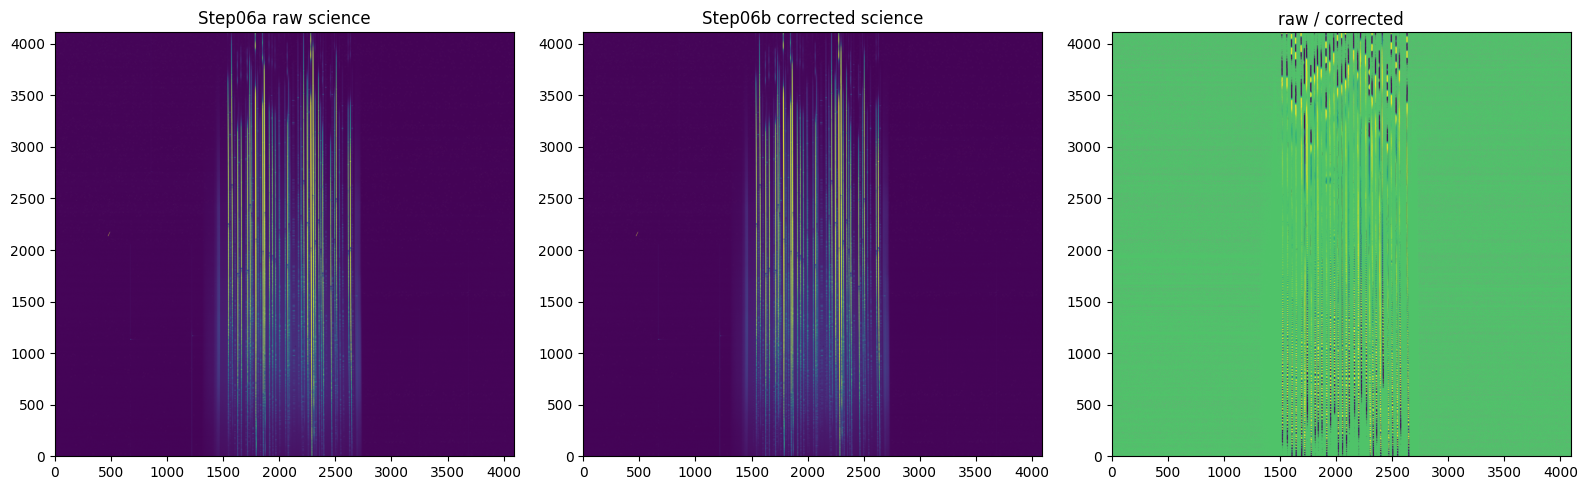

In [11]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

st06 = Path(config.ST06_SCIENCE)
base_candidates = sorted(st06.glob("FinalScience*_ADUperS.fits"))
if not base_candidates:
    raise FileNotFoundError(f"No FinalScience ADUperS mosaic found in {st06}")

base_path = base_candidates[-1]

corr_even = sorted(st06.glob("FinalScience*pixflatcorr*EVEN.fits"))
if not corr_even:
    raise FileNotFoundError("No EVEN Step06b product found.")
corr_path = corr_even[-1]

raw = fits.getdata(base_path)
corr = fits.getdata(corr_path)

ratio = np.full_like(raw, np.nan, dtype=float)
m = np.isfinite(raw) & np.isfinite(corr) & (corr != 0)
ratio[m] = raw[m] / corr[m]

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

vmin = np.nanpercentile(raw[np.isfinite(raw)], 5)
vmax = np.nanpercentile(raw[np.isfinite(raw)], 99)
ax[0].imshow(raw, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
ax[0].set_title("Step06a raw science")

vmin2 = np.nanpercentile(corr[np.isfinite(corr)], 5)
vmax2 = np.nanpercentile(corr[np.isfinite(corr)], 99)
ax[1].imshow(corr, origin="lower", aspect="auto", vmin=vmin2, vmax=vmax2)
ax[1].set_title("Step06b corrected science")

good = ratio[np.isfinite(ratio)]
rv1 = np.nanpercentile(good, 1)
rv2 = np.nanpercentile(good, 99)
ax[2].imshow(ratio, origin="lower", aspect="auto", vmin=rv1, vmax=rv2)
ax[2].set_title("raw / corrected")

plt.tight_layout()


### Step06b QC

There are two useful QC layers here.

1. **Full-frame inspection** of raw / flat / corrected / masked corrected
2. **Registered vs non-registered comparison**, if you are testing `REGFLAT=True`


In [13]:
# Uncomment to run Step06b QC
#run_repo_script("qc/step06/qc_step06b_inspector_final.py", "--traceset", "EVEN")
#run_repo_script("qc/step06/qc_step06b_inspector_final.py", "--traceset", "ODD")

# Optional: compare registered vs non-registered branches
# run_repo_script("qc/step06/qc_step06b_compare_reg_final.py", "--traceset", "EVEN")
# run_repo_script("qc/step06/qc_step06b_compare_reg_final.py", "--traceset", "ODD")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step06/qc_step06b_inspector_final.py --traceset EVEN
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline

Step06b QC summary for EVEN (reg=False)
Science   : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/FinalScience_dolidze_ADUperS.fits
Corrected : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/science_pixflat

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step06/qc_step06b_inspector_final.py', '--traceset', 'ODD'], returncode=0)

## 5. Quartz geometry vs science alignment

This is one of the most important QC checks in Step06.

The overlay QC draws the Step04 quartz-derived centerline and edges directly on the Step06 science image. It answers a very direct question:

> Does the quartz geometry still follow the actual science trace on the detector?

This is the best diagnostic for quartz–science misalignment.


In [14]:
# Uncomment to run the Step04-on-science overlay QC
run_repo_script("qc/step06/qc_step06c—overlay_Step04_trace_geometry_on_science_image.py", "--traceset", "EVEN")
run_repo_script("qc/step06/qc_step06c—overlay_Step04_trace_geometry_on_science_image.py", "--traceset", "ODD")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step06/qc_step06c—overlay_Step04_trace_geometry_on_science_image.py --traceset EVEN
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
[INFO] Science : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/science_pixflatcorr_even.fits
[INFO] Geometry: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces/Even_traces_geometry

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step06/qc_step06c—overlay_Step04_trace_geometry_on_science_image.py', '--traceset', 'ODD'], returncode=0)

## 6. Step06c — rectify slitlets into TRACECOORDS

Step06c uses the Step04 slitid, geometry, and slit table to map the curved slit traces into rectangular slit frames.

Important design points:

- rectification is geometric only
- Step06c does **not** perform wavelength calibration
- output is MEF: one HDU per slit
- the result is still a 2D slit image, not yet a 1D spectrum

Typical output naming:

```text
FinalScience_*_pixflatcorr_clipped_EVEN_tracecoords.fits
FinalScience_*_pixflatcorr_clipped_ODD_tracecoords.fits
```


In [15]:
# Uncomment to run Step06c
run_repo_script("pipeline/step06_science_rectify/step06c_rectify_tracecoords.py", "--traceset", "EVEN")
run_repo_script("pipeline/step06_science_rectify/step06c_rectify_tracecoords.py", "--traceset", "ODD")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step06_science_rectify/step06c_rectify_tracecoords.py --traceset EVEN
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline


2026-04-09 16:05:28,928 | INFO     | step06c_rectify_edgeswarp_clean | Input   : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/FinalScience_dolidze_ADUperS_pixflatcorr_clipped_EVEN.fits
2026-04-09 16:05:28,928 | INFO     | step06c_rectify_edgeswarp_clean | SlitID  : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces/Even_traces_slitid.fits
2026-04-09 16:05:28,928 | INFO     | step06c_rectify_edgeswarp_clean | Geometry: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces/Even_traces_geometry.fits
2026-04-09 16:05:28,928 | INFO     | step06c_rectify_edgeswarp_clean | Widths  : /Users/robberto/Library/CloudStorage/B

Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step06_science_rectify/step06c_rectify_tracecoords.py --traceset ODD
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline


2026-04-09 16:05:31,009 | INFO     | step06c_rectify_edgeswarp_clean | Input   : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/FinalScience_dolidze_ADUperS_pixflatcorr_clipped_ODD.fits
2026-04-09 16:05:31,009 | INFO     | step06c_rectify_edgeswarp_clean | SlitID  : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces/Odd_traces_slitid.fits
2026-04-09 16:05:31,009 | INFO     | step06c_rectify_edgeswarp_clean | Geometry: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces/Odd_traces_geometry.fits
2026-04-09 16:05:31,009 | INFO     | step06c_rectify_edgeswarp_clean | Widths  : /Users/robberto/Library/CloudStorage/Box-

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step06_science_rectify/step06c_rectify_tracecoords.py', '--traceset', 'ODD'], returncode=0)

In [16]:
from pathlib import Path
from astropy.io import fits

st06 = Path(config.ST06_SCIENCE)
for p in sorted(st06.glob("*_tracecoords.fits")):
    print(p.name)


FinalScience_dolidze_ADUperS_pixflatcorr_EVEN_tracecoords.fits
FinalScience_dolidze_ADUperS_pixflatcorr_ODD_tracecoords.fits
FinalScience_dolidze_ADUperS_pixflatcorr_clipped_EVEN_tracecoords.fits
FinalScience_dolidze_ADUperS_pixflatcorr_clipped_ODD_tracecoords.fits


Using: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/FinalScience_dolidze_ADUperS_pixflatcorr_clipped_EVEN_tracecoords.fits
N HDUs = 33
First HDUs: ['PRIMARY', 'SLIT000', 'SLIT002', 'SLIT004', 'SLIT006', 'SLIT008', 'SLIT010', 'SLIT012', 'SLIT014', 'SLIT016']
Example slit: SLIT000 (4112, 31)


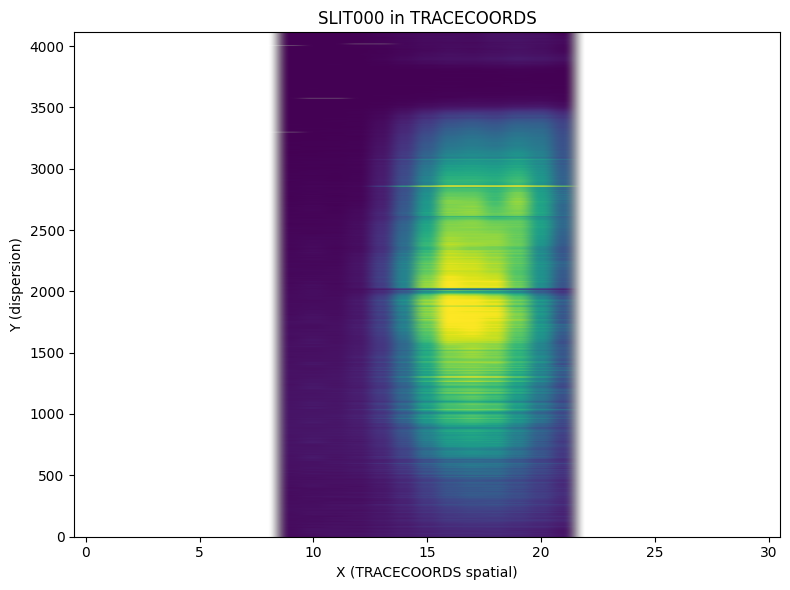

In [17]:
from pathlib import Path
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

st06 = Path(config.ST06_SCIENCE)
tc_files = sorted(st06.glob("*_EVEN_tracecoords.fits"))
if not tc_files:
    tc_files = sorted(st06.glob("*_tracecoords.fits"))

if not tc_files:
    raise FileNotFoundError(f"No TRACECOORDS product found in {st06}")

tc_path = tc_files[-1]
print("Using:", tc_path)

with fits.open(tc_path) as hdul:
    print("N HDUs =", len(hdul))
    names = [h.name for h in hdul[:10]]
    print("First HDUs:", names)

    slit_hdu = None
    for h in hdul[1:]:
        if h.data is not None and (h.name or "").startswith("SLIT"):
            slit_hdu = h
            break

    if slit_hdu is None:
        raise RuntimeError("No SLIT extension found.")

    img = slit_hdu.data.astype(float)
    print("Example slit:", slit_hdu.name, img.shape)

vmin = np.nanpercentile(img[np.isfinite(img)], 5)
vmax = np.nanpercentile(img[np.isfinite(img)], 99)

plt.figure(figsize=(8, 6))
plt.imshow(img, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
plt.title(f"{slit_hdu.name} in TRACECOORDS")
plt.xlabel("X (TRACECOORDS spatial)")
plt.ylabel("Y (dispersion)")
plt.tight_layout()


## 7. Step06c QC

There are two complementary QC layers for TRACECOORDS.

### Quicklook QC
This creates one JPG per slit and a montage for the first N slitlets. It is the fastest way to check whether the rectified slit images look plausible.

### Single-slit diagnostic
This provides a deeper audit of one slit, including:
- valid footprint per row
- width stability
- blank-row fraction
- left/right footprint boundaries


In [22]:
# Uncomment to run Step06c QC
run_repo_script("qc/step06/qc_step06c_quicklooks_final.py", "--traceset", "EVEN")
run_repo_script("qc/step06/qc_step06c_quicklooks_final.py", "--traceset", "ODD")

# Optional deep inspection of one slit
run_repo_script("qc/step06/qc_step06c_single_final.py", "--traceset", "EVEN", "--slit", "SLIT018")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step06/qc_step06c_quicklooks_final.py --traceset EVEN
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
[INFO] Reading: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/FinalScience_dolidze_ADUperS_pixflatcorr_clipped_EVEN_tracecoords.fits
[OK] montage: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/qc_step06c_e

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step06/qc_step06c_single_final.py', '--traceset', 'EVEN', '--slit', 'SLIT018'], returncode=0)

## 8. Display the Step06c montage products

These are the most useful visual QC artifacts to embed in the notebook once the quicklook script has been run.


Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/qc_step06c_even/FinalScience_dolidze_ADUperS_pixflatcorr_EVEN_tracecoords_montage_ybin12.jpg


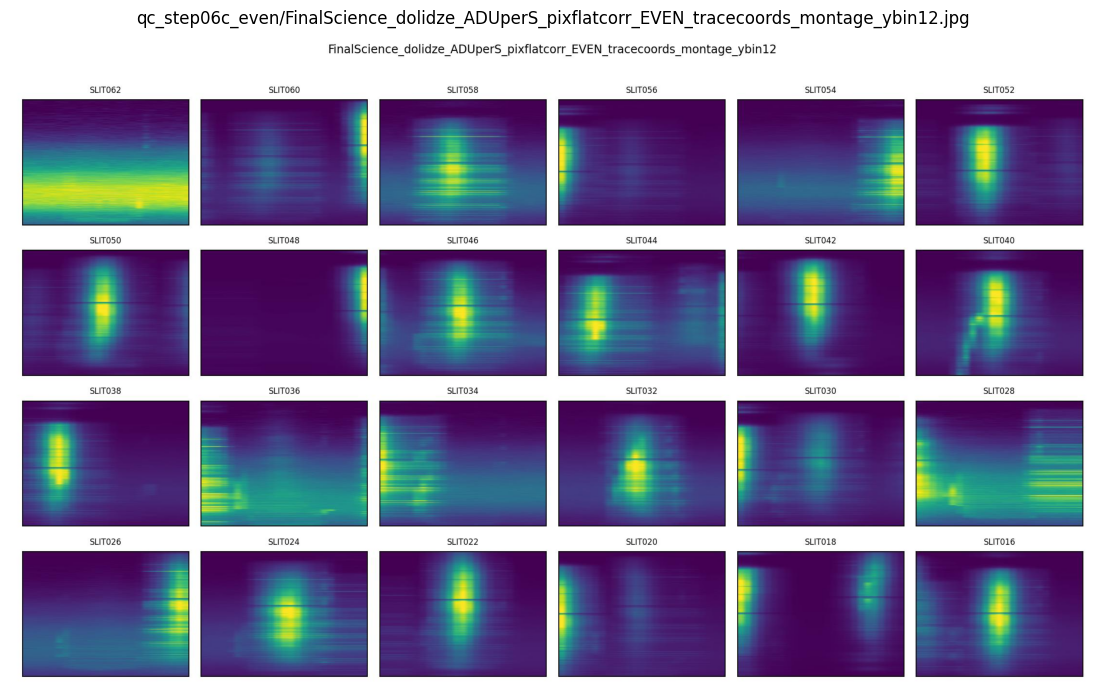

Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/qc_step06c_even/FinalScience_dolidze_ADUperS_pixflatcorr_clipped_EVEN_tracecoords_montage_ybin12.jpg


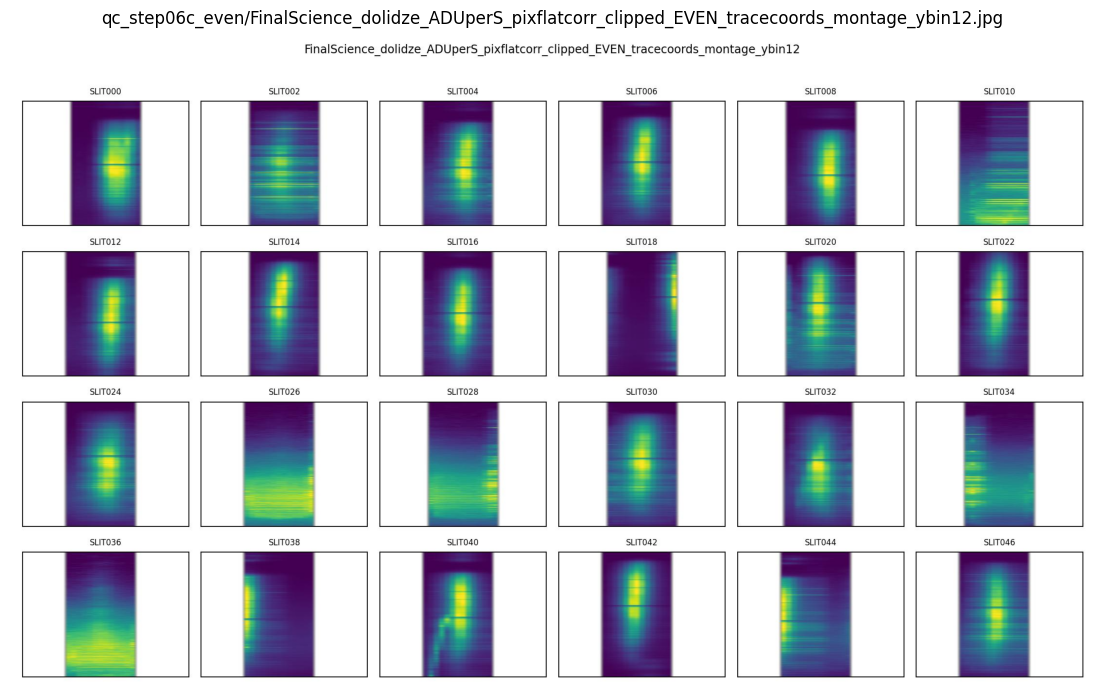

Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/qc_step06c_odd/FinalScience_dolidze_ADUperS_pixflatcorr_ODD_tracecoords_montage_ybin12.jpg


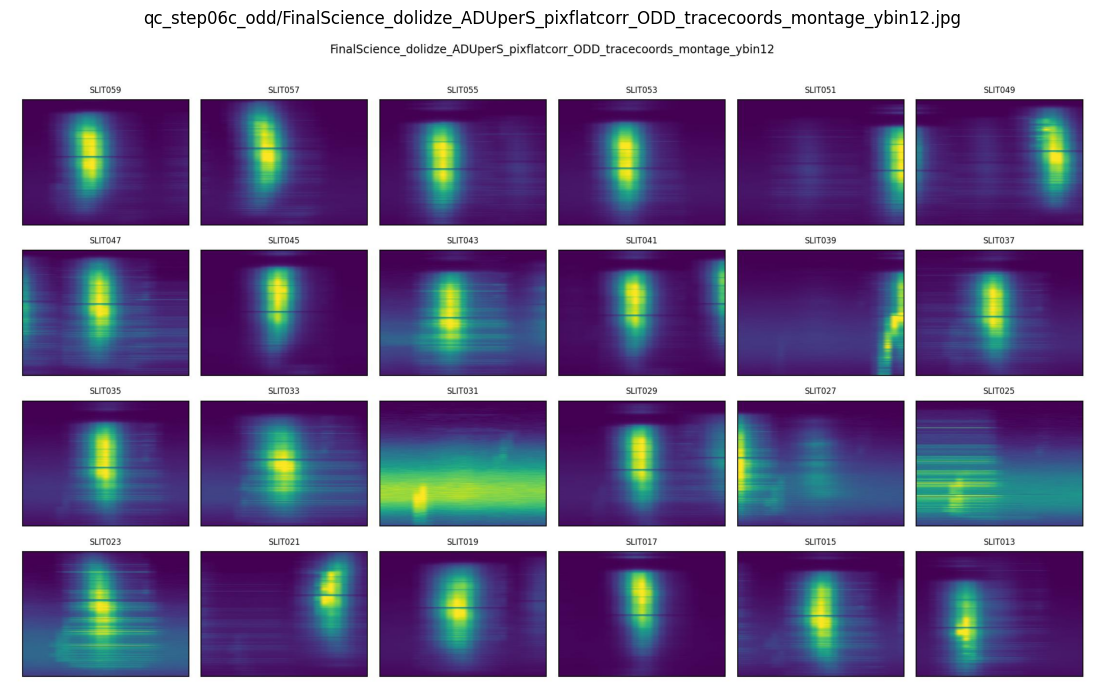

Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/06_science/qc_step06c_odd/science_tracecoords_odd_montage_ybin12.jpg


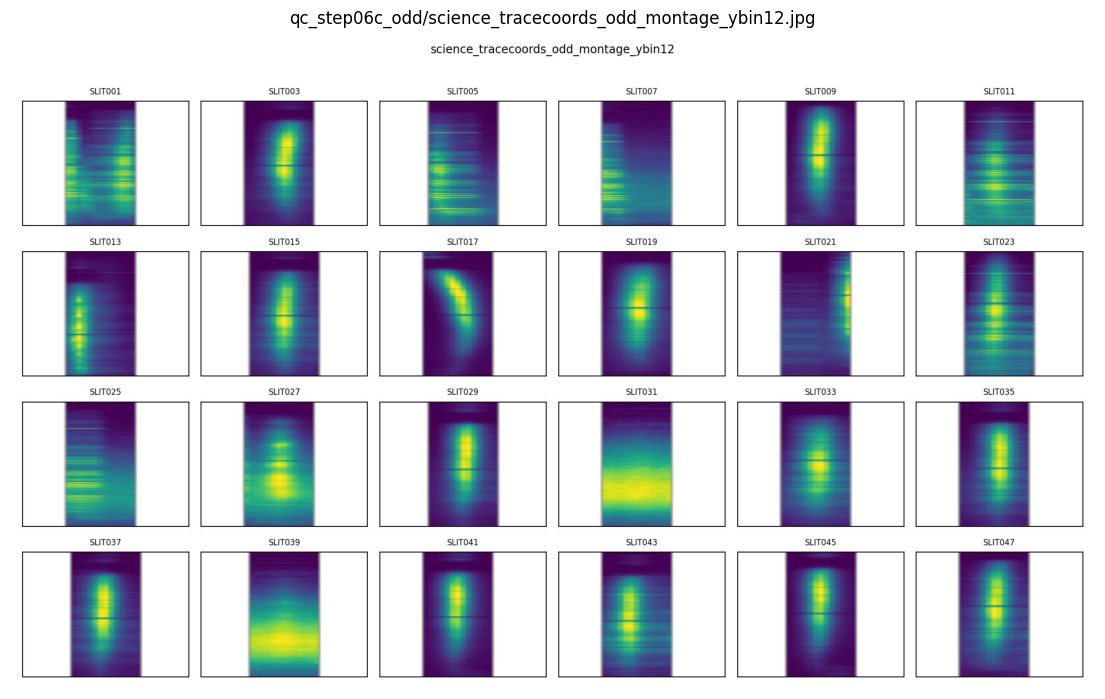

In [24]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import config

st06 = Path(config.ST06_SCIENCE)

# Search flexibly for the montage products actually written by qc_step06c_quicklooks_final.py
candidates = sorted((st06 / "qc_step06c_even").glob("*montage*.jpg")) + \
             sorted((st06 / "qc_step06c_odd").glob("*montage*.jpg"))

if not candidates:
    print("No montage JPGs found under:")
    print(" -", st06 / "qc_step06c_even")
    print(" -", st06 / "qc_step06c_odd")
else:
    for p in candidates:
        print("Displaying:", p)
        img = Image.open(p)
        plt.figure(figsize=(14, 10))
        plt.imshow(img)
        plt.axis("off")
        plt.title(str(p.relative_to(st06)))
        plt.show()

## 9. Minimal end-to-end Step06 checklist

A practical Step06 session usually looks like this:

1. verify Step03.5, Step04, and Step05 inputs exist
2. run Step06a
3. inspect the full-frame mosaic
4. run Step06a QC
5. run Step06b for EVEN and ODD
6. inspect Step06b products and QC
7. run the Step04-on-science overlay QC
8. run Step06c for EVEN and ODD
9. inspect one TRACECOORDS slit
10. run Step06c quicklooks and, if needed, single-slit QC


## 10. What a good Step06 result should look like

### Step06a
- smooth full-frame mosaic
- plausible normalization
- no obvious combine seams or blank regions

### Step06b
- corrected frame behaves consistently with the flat
- no correction outside the intended slit footprint
- clipping stays moderate
- optional registration does not introduce harmful structure

### Step06 overlay QC
- Step04 centerline and edges follow the science trace well

### Step06c
- slitlets are rectangular and finite where expected
- widths remain plausible
- few blank rows
- no obvious edge truncation or broken slit footprints


## 11. Summary of the infrastructure lesson

Step06 is the first place where the notebook should make the architecture very explicit.

The key practical lessons are:

- Step06a is the only full-frame baseline science product
- Step06b splits into EVEN and ODD branches
- Step06c is TRACECOORDS-only, not wavelength calibrated
- Step04 geometry is reused, not re-fit
- robust path handling in notebooks is essential because these steps launch many stand-alone scripts
